# Entendimento inicial do dataset de voos

Este notebook explora o CSV derivado e a base de modelagem do Voo Regular Ativo (VRA) da ANAC. Ele não treina modelos. O objetivo é verificar estrutura, cobertura, qualidade, distribuição das seis faixas de atraso e outliers antes de definir as variáveis preditoras.

Para gerar a base local, execute primeiro o notebook `00_preparar_dados.ipynb`. O CSV é local e não é versionado.

### Importar as bibliotecas

Importamos as bibliotecas usadas para manipulação dos dados e visualização dos resultados.

In [24]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

### Configurar a exibição das tabelas

Aumentamos a quantidade de colunas e linhas exibidas pelo pandas para facilitar a inspeção exploratória. Essa configuração não altera os dados.

In [25]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

### Localizar a raiz do projeto

O notebook pode ser aberto a partir da raiz do projeto ou da pasta `notebooks`. Procuramos a pasta `data` subindo pelos diretórios para tornar os caminhos independentes do diretório de abertura.

In [26]:
ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent
print('Raiz do projeto:', ROOT)

Raiz do projeto: /home/falberto/Git/mcdia/mcdia-ml-previsao-atraso-voos


### Localizar e validar as bases

Definimos os caminhos do dataset derivado e da base de modelagem e verificamos se o notebook `00_preparar_dados.ipynb` já foi executado.

In [27]:
DATA_PATH = ROOT / 'data' / 'voos_vra_derivados.csv'
MODELAGEM_PATH = ROOT / 'data' / 'modelagem_faixas_atraso.csv'
for path in [DATA_PATH, MODELAGEM_PATH]:
    if not path.exists():
        raise FileNotFoundError(f'Arquivo não encontrado: {path}. Execute o notebook 00 primeiro.')
DATA_PATH, MODELAGEM_PATH

(PosixPath('/home/falberto/Git/mcdia/mcdia-ml-previsao-atraso-voos/data/voos_vra_derivados.csv'),
 PosixPath('/home/falberto/Git/mcdia/mcdia-ml-previsao-atraso-voos/data/modelagem_faixas_atraso.csv'))

### Carregamento do dataset

Agora lemos o CSV derivado e a base de modelagem. Os quatro campos de data e hora do dataset derivado são convertidos para o tipo de data do pandas. A base de modelagem já contém `faixa_atraso` e as variáveis temporais usadas posteriormente.

In [28]:
date_columns = ['partida_prevista', 'partida_real', 'chegada_prevista', 'chegada_real']
df = pd.read_csv(DATA_PATH, parse_dates=date_columns, low_memory=False)
modelagem = pd.read_csv(MODELAGEM_PATH, low_memory=False)
print('Dataset derivado:', df.shape)
print('Base de modelagem:', modelagem.shape)
df.head(3)

Dataset derivado: (1992832, 25)
Base de modelagem: (1863908, 16)


,companhia_icao,empresa,numero_voo,codigo_di,codigo_tipo_linha,modelo_equipamento,numero_assentos,origem_icao,origem_descricao,partida_prevista,partida_real,destino_icao,destino_descricao,chegada_prevista,chegada_real,situacao_voo,situacao_partida,situacao_chegada,codeshare,cancelado,realizado,atraso_partida_min,atraso_chegada_min,arquivo_origem,linha_origem
0,AAL,"AMERICAN AIRLINES, INC.",0904,0,I,B772,288,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,2024-01-01 23:55:00,2024-01-01 23:47:00,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-02 07:45:00,2024-01-02 08:19:00,REALIZADO,Antecipado,Atraso 30-60,GLO/6004,False,True,-8.0,34.0,VRA_2024_01.csv,1
1,AAL,"AMERICAN AIRLINES, INC.",0905,0,I,B772,288,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 23:55:00,2024-01-01 01:29:00,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,2024-01-02 09:25:00,2024-01-01 09:35:00,REALIZADO,Antecipado,Antecipado,GLO/6005,False,True,-1346.0,-1430.0,VRA_2024_01.csv,2
2,AAL,"AMERICAN AIRLINES, INC.",0906,0,I,B77W,318,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,2024-01-01 00:55:00,2024-01-01 00:46:00,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 08:35:00,2024-01-01 08:45:00,REALIZADO,Antecipado,Pontual,GLO/6006,False,True,-9.0,10.0,VRA_2024_01.csv,3


## 1. Exploração rápida para iniciantes

Depois de carregar uma base, é útil fazer algumas perguntas simples: quantas linhas e colunas existem, como são os primeiros registros, quais tipos de dados foram reconhecidos e quais são as principais estatísticas numéricas. Estas operações são descritivas: ajudam a entender a base antes de formular modelos.

### Tamanho e primeiras linhas

shape informa o número de linhas e colunas. head() mostra os primeiros registros para conferirmos se os dados foram carregados como esperado.

In [29]:
print('Linhas e colunas:', df.shape)
df.head()

Linhas e colunas: (1992832, 25)


,companhia_icao,empresa,numero_voo,codigo_di,codigo_tipo_linha,modelo_equipamento,numero_assentos,origem_icao,origem_descricao,partida_prevista,partida_real,destino_icao,destino_descricao,chegada_prevista,chegada_real,situacao_voo,situacao_partida,situacao_chegada,codeshare,cancelado,realizado,atraso_partida_min,atraso_chegada_min,arquivo_origem,linha_origem
0,AAL,"AMERICAN AIRLINES, INC.",0904,0,I,B772,288,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,2024-01-01 23:55:00,2024-01-01 23:47:00,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-02 07:45:00,2024-01-02 08:19:00,REALIZADO,Antecipado,Atraso 30-60,GLO/6004,False,True,-8.0,34.0,VRA_2024_01.csv,1
1,AAL,"AMERICAN AIRLINES, INC.",0905,0,I,B772,288,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 23:55:00,2024-01-01 01:29:00,SBGL,AEROPORTO INTERNACIONAL DO RIO DE JANEIRO (GAL...,2024-01-02 09:25:00,2024-01-01 09:35:00,REALIZADO,Antecipado,Antecipado,GLO/6005,False,True,-1346.0,-1430.0,VRA_2024_01.csv,2
2,AAL,"AMERICAN AIRLINES, INC.",0906,0,I,B77W,318,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,2024-01-01 00:55:00,2024-01-01 00:46:00,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 08:35:00,2024-01-01 08:45:00,REALIZADO,Antecipado,Pontual,GLO/6006,False,True,-9.0,10.0,VRA_2024_01.csv,3
3,AAL,"AMERICAN AIRLINES, INC.",0925,0,I,B772,288,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 21:20:00,2024-01-01 23:17:00,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,2024-01-02 07:50:00,2024-01-02 07:47:00,REALIZADO,Atraso 60-120,Antecipado,NaN,False,True,117.0,-3.0,VRA_2024_01.csv,4
4,AAL,"AMERICAN AIRLINES, INC.",0929,0,I,B77W,318,KMIA,"MIAMI INTERNATIONAL AIRPORT - MIAMI, FLORIDA -...",2024-01-01 20:50:00,2024-01-01 21:51:00,SBGR,GUARULHOS - GOVERNADOR ANDRÉ FRANCO MONTORO - ...,2024-01-02 06:20:00,2024-01-02 06:13:00,REALIZADO,Atraso 60-120,Antecipado,GLO/6007,False,True,61.0,-7.0,VRA_2024_01.csv,5


### Tipos das colunas e memória usada

info() resume o tipo de cada coluna, a quantidade de valores preenchidos e o uso aproximado de memória. É uma verificação importante para descobrir, por exemplo, se uma data foi lida como data ou como texto.

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1992832 entries, 0 to 1992831
Data columns (total 25 columns):
 #   Column              Dtype         
---  ------              -----         
 0   companhia_icao      str           
 1   empresa             str           
 2   numero_voo          str           
 3   codigo_di           str           
 4   codigo_tipo_linha   str           
 5   modelo_equipamento  str           
 6   numero_assentos     int64         
 7   origem_icao         str           
 8   origem_descricao    str           
 9   partida_prevista    datetime64[us]
 10  partida_real        datetime64[us]
 11  destino_icao        str           
 12  destino_descricao   str           
 13  chegada_prevista    datetime64[us]
 14  chegada_real        datetime64[us]
 15  situacao_voo        str           
 16  situacao_partida    str           
 17  situacao_chegada    str           
 18  codeshare           str           
 19  cancelado           bool          
 20  realizado    

### Estatísticas numéricas com describe()

describe() calcula automaticamente estatísticas das colunas numéricas: quantidade (count), média (mean), desvio padrão (std), mínimo, quartis e máximo. O primeiro quartil é 25%, a mediana é 50% e o terceiro quartil é 75%.

In [31]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
numero_assentos,1992832.0,161.905437,0.0,136.0,180.0,186.0,515.0,69.141734
partida_prevista,1933691,2025-01-03 05:38:58.680131,2024-01-01 00:05:00,2024-07-07 09:45:00,2025-01-05 03:30:00,2025-07-05 05:00:00,2026-01-02 09:05:00,NaN
partida_real,1923336,2025-01-04 12:57:44.201605,2023-12-31 19:23:00,2024-07-08 06:47:45,2025-01-07 05:49:00,2025-07-07 07:17:15,2026-01-01 19:05:00,NaN
chegada_prevista,1933689,2025-01-03 08:18:46.531526,2024-01-01 01:10:00,2024-07-07 12:00:00,2025-01-05 07:25:00,2025-07-05 07:30:00,2026-01-02 14:50:00,NaN
chegada_real,1923336,2025-01-04 15:31:44.697212,2024-01-01 01:04:00,2024-07-08 08:56:45,2025-01-07 08:14:30,2025-07-07 09:41:15,2026-01-01 21:52:00,NaN
atraso_partida_min,1864195.0,7.621729,-5760.0,-7.0,-1.0,9.0,44635.0,74.588181
atraso_chegada_min,1864195.0,3.851277,-5784.0,-12.0,-4.0,8.0,44625.0,75.59674
linha_origem,1992832.0,41588.69567,1.0,20759.0,41518.0,62276.25,89616.0,24093.085546


### Média, mediana e outras medidas explicitamente

Também podemos pedir as medidas diretamente com agg(). A média pode ser influenciada por atrasos muito grandes; por isso comparamos com a mediana, que representa melhor o valor central quando há outliers.

In [32]:
colunas_numericas = ['atraso_partida_min', 'atraso_chegada_min']
resumo_central = df[colunas_numericas].agg(['count', 'mean', 'median', 'std', 'min', 'max']).T
resumo_central

,count,mean,median,std,min,max
atraso_partida_min,1864195.0,7.621729,-1.0,74.588181,-5760.0,44635.0
atraso_chegada_min,1864195.0,3.851277,-4.0,75.596740,-5784.0,44625.0


### Contagem de categorias

Para colunas categóricas, value_counts() mostra quantos registros pertencem a cada categoria. Aqui verificamos a situação operacional dos voos.

In [33]:
df['situacao_voo'].value_counts(dropna=False)

situacao_voo
REALIZADO    1923336
CANCELADO      69496
Name: count, dtype: int64

## 2. Schema e qualidade básica

As colunas de horários reais e situações operacionais são rótulos ou informações posteriores. Elas não devem entrar como preditoras no primeiro experimento.

### Dicionário de tipos e valores ausentes

Esta tabela mostra o tipo de cada coluna e quantos valores estão ausentes. Use-a para identificar quais campos podem ser usados com segurança.

In [34]:
schema = pd.DataFrame({'tipo': df.dtypes.astype(str), 'ausentes': df.isna().sum(), 'percentual_ausente': (100 * df.isna().mean()).round(2)})
schema

,tipo,ausentes,percentual_ausente
companhia_icao,str,0,0.00
empresa,str,0,0.00
numero_voo,str,0,0.00
codigo_di,str,0,0.00
codigo_tipo_linha,str,464,0.02
modelo_equipamento,str,0,0.00
numero_assentos,int64,0,0.00
origem_icao,str,0,0.00
origem_descricao,str,0,0.00
partida_prevista,datetime64[us],59141,2.97


### Duplicidades e situações operacionais

Aqui verificamos registros repetidos e observamos quantos voos foram realizados ou cancelados, além das categorias de situação da chegada.

In [35]:
print('Duplicidades:', int(df.duplicated().sum()))
print('Arquivos de origem:', df['arquivo_origem'].value_counts().sort_index().to_dict())
print('Situação do voo:')
display(df['situacao_voo'].value_counts(dropna=False).to_frame('quantidade'))
print('Situação da chegada:')
display(df['situacao_chegada'].value_counts(dropna=False).to_frame('quantidade'))

Duplicidades: 0
Arquivos de origem: {'VRA_2024_01.csv': 86559, 'VRA_2024_02.csv': 77121, 'VRA_2024_03.csv': 81432, 'VRA_2024_04.csv': 80640, 'VRA_2024_05.csv': 78816, 'VRA_2024_06.csv': 77981, 'VRA_2024_07.csv': 87683, 'VRA_2024_08.csv': 85310, 'VRA_2024_09.csv': 81382, 'VRA_2024_10.csv': 84232, 'VRA_2024_11.csv': 79949, 'VRA_2024_12.csv': 85919, 'VRA_2025_01.csv': 89616, 'VRA_2025_02.csv': 78930, 'VRA_2025_03.csv': 82048, 'VRA_2025_04.csv': 80692, 'VRA_2025_05.csv': 82565, 'VRA_2025_06.csv': 80974, 'VRA_2025_07.csv': 87725, 'VRA_2025_08.csv': 84584, 'VRA_2025_09.csv': 82156, 'VRA_2025_10.csv': 85709, 'VRA_2025_11.csv': 82245, 'VRA_2025_12.csv': 88564}
Situação do voo:


,quantidade
situacao_voo,
REALIZADO,1923336
CANCELADO,69496


Situação da chegada:


,quantidade
situacao_chegada,
Antecipado,1106889
Pontual,589741
NaN,128637
Atraso 30-60,95243
Atraso 60-120,45038
Atraso 120-240,18460
Atraso > 240,8824


## 3. Alvo e distribuição das classes

`cancelado` é uma situação operacional separada. Para previsão de atraso, usamos somente voos realizados com atraso de chegada calculável. O alvo principal é `faixa_atraso`, uma classificação ordinal com seis classes.

### Resumo do alvo e das faixas

Esta célula quantifica cancelamentos, voos realizados, registros elegíveis para modelagem e a distribuição das seis faixas de atraso.

In [36]:
FAIXAS = {
    0: 'Pontual ou antecipado',
    1: 'Atraso inferior a 15 min',
    2: 'Atraso de 15 a 30 min',
    3: 'Atraso superior a 30 até 45 min',
    4: 'Atraso superior a 45 até 60 min',
    5: 'Atraso superior a 60 min',
}
target_summary = pd.DataFrame({
    'quantidade': [df['cancelado'].sum(), df['realizado'].sum(), len(modelagem)],
}, index=['cancelados', 'realizados', 'registros_elegíveis_para_modelagem'])
distribuicao_faixas = modelagem['faixa_atraso'].value_counts().reindex(FAIXAS.keys(), fill_value=0).rename('quantidade').to_frame()
distribuicao_faixas.index.name = 'codigo'
distribuicao_faixas['classificacao'] = distribuicao_faixas.index.map(FAIXAS)
distribuicao_faixas['percentual'] = (100 * distribuicao_faixas['quantidade'] / len(modelagem)).round(2)
display(target_summary)
display(distribuicao_faixas[['classificacao', 'quantidade', 'percentual']])

,quantidade
cancelados,69496
realizados,1923336
registros_elegíveis_para_modelagem,1863908


,classificacao,quantidade,percentual
codigo,,,
0,Pontual ou antecipado,1154800,61.96
1,Atraso inferior a 15 min,379371,20.35
2,Atraso de 15 a 30 min,161958,8.69
3,Atraso superior a 30 até 45 min,63342,3.40
4,Atraso superior a 45 até 60 min,32026,1.72
5,Atraso superior a 60 min,72411,3.88


### Estatísticas dos atrasos

Calculamos percentis do atraso de partida e de chegada apenas para voos realizados. Os valores negativos representam antecipação.

In [37]:
realizados = df[df['realizado']].copy()
realizados[['atraso_partida_min', 'atraso_chegada_min']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2)

,atraso_partida_min,atraso_chegada_min
count,1864195.00,1864195.00
mean,7.62,3.85
std,74.59,75.60
min,-5760.00,-5784.00
1%,-20.00,-36.00
5%,-13.00,-23.00
25%,-7.00,-12.00
50%,-1.00,-4.00
75%,9.00,8.00
95%,51.00,50.00


## 4. Distribuição e outliers

A amostra já revelou registros com atrasos superiores a 24 horas e casos acima de 30 dias. Esses valores não devem ser removidos automaticamente. A classificação em faixas reduz a sensibilidade a diferenças extremas dentro da mesma classe, mas uma regressão em minutos exigiria uma regra de tratamento definida antes da avaliação.

### Investigação de outliers

Esta tabela lista os maiores atrasos de chegada. Observe especialmente os casos acima de 24 horas antes de decidir qualquer tratamento.

In [38]:
outliers = realizados[realizados['atraso_chegada_min'] > 24 * 60].sort_values('atraso_chegada_min', ascending=False)
print('Atrasos de chegada acima de 24 horas:', len(outliers))
outliers[['arquivo_origem', 'companhia_icao', 'numero_voo', 'origem_icao', 'destino_icao', 'chegada_prevista', 'chegada_real', 'atraso_chegada_min', 'situacao_chegada']].head(20)

Atrasos de chegada acima de 24 horas: 495


,arquivo_origem,companhia_icao,numero_voo,origem_icao,destino_icao,chegada_prevista,chegada_real,atraso_chegada_min,situacao_chegada
987636,VRA_2025_01.csv,ABJ,1407,SNCL,SBSV,2025-01-03 14:15:00,2025-02-03 14:00:00,44625.0,Atraso > 240
1208763,VRA_2025_03.csv,LAE,1817,SBKP,SKBO,2025-03-17 14:50:00,2025-03-23 02:46:00,7916.0,Atraso > 240
1399846,VRA_2025_05.csv,TPA,4054,SBKP,SKBO,2025-05-08 21:15:00,2025-05-14 09:08:00,7913.0,Atraso > 240
1789335,VRA_2025_10.csv,GTI,0046,SBGL,SCEL,2025-10-23 22:50:00,2025-10-29 06:54:00,7684.0,Atraso > 240
54133,VRA_2024_01.csv,GTI,8230,SBGR,SCEL,2024-01-30 12:55:00,2024-02-03 21:45:00,6290.0,Atraso > 240
436024,VRA_2024_06.csv,FDX,0041,SBKP,KMEM,2024-06-26 03:00:00,2024-06-30 04:42:00,5862.0,Atraso > 240
770483,VRA_2024_10.csv,FDX,0041,SBKP,KMEM,2024-10-23 02:50:00,2024-10-27 00:44:00,5634.0,Atraso > 240
54134,VRA_2024_01.csv,GTI,8230,KMIA,SBGR,2024-01-30 05:50:00,2024-02-03 00:44:00,5454.0,Atraso > 240
623258,VRA_2024_08.csv,GTI,8230,KMIA,SBGR,2024-08-27 05:40:00,2024-08-30 23:20:00,5380.0,Atraso > 240
1621528,VRA_2025_08.csv,GTI,0064,SBKP,SPJC,2025-08-27 21:10:00,2025-08-31 14:50:00,5380.0,Atraso > 240


### Visualização da distribuição

Os gráficos mostram a distribuição dos atrasos em minutos e a quantidade de registros em cada uma das seis classes ordinais.

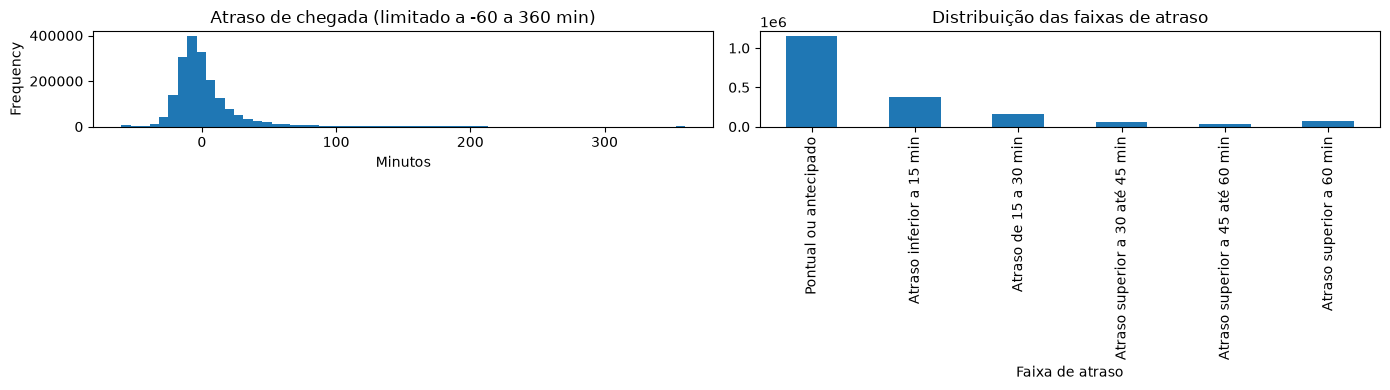

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
realizados['atraso_chegada_min'].clip(-60, 360).plot.hist(bins=60, ax=axes[0], title='Atraso de chegada (limitado a -60 a 360 min)')
modelagem['faixa_atraso'].value_counts().sort_index().rename(index=FAIXAS).plot.bar(ax=axes[1], title='Distribuição das faixas de atraso')
axes[0].set_xlabel('Minutos')
axes[1].set_xlabel('Faixa de atraso')
plt.tight_layout()

## 5. Padrões por tempo, companhia e aeroporto

Estas tabelas mostram como as seis classes se distribuem ao longo do tempo e entre grupos. São descritivas, não demonstram causalidade e não devem ser usadas diretamente como estimativas do desempenho futuro sem uma divisão temporal.

### Evolução por mês

Resumimos o volume de cada faixa de atraso por mês de referência. A tabela ajuda a identificar mudanças na composição do alvo ao longo do tempo.

In [40]:
monthly = pd.crosstab(modelagem['mes_referencia'], modelagem['faixa_atraso'])
monthly = monthly.reindex(columns=FAIXAS.keys(), fill_value=0)
monthly = monthly.rename(columns=FAIXAS)
monthly['total_voos'] = monthly.sum(axis=1)
monthly

faixa_atraso,Pontual ou antecipado,Atraso inferior a 15 min,Atraso de 15 a 30 min,Atraso superior a 30 até 45 min,Atraso superior a 45 até 60 min,Atraso superior a 60 min,total_voos
mes_referencia,,,,,,,
2024-01,43895,16763,8387,3604,1710,3671,78030
2024-02,44361,13397,6217,2472,1218,2551,70216
2024-03,47806,14764,6093,2369,1237,2922,75191
2024-04,48785,15115,5854,2116,1017,2429,75316
2024-05,46978,15133,5687,1938,971,2233,72940
2024-06,47138,15603,5526,1926,956,2245,73394
2024-07,52603,16885,6332,2254,1158,2905,82137
2024-08,48520,16964,6784,2627,1282,3104,79281
2024-09,46975,16118,6497,2351,1141,2681,75763


### Comparação por companhia

Esta tabela compara a quantidade de voos em cada faixa por companhia, considerando companhias com pelo menos 100 voos. Ela é descritiva e não deve ser interpretada como ranking de desempenho.

In [41]:
by_carrier = pd.crosstab(modelagem['companhia_icao'], modelagem['faixa_atraso'])
by_carrier = by_carrier.reindex(columns=FAIXAS.keys(), fill_value=0).rename(columns=FAIXAS)
by_carrier['total_voos'] = by_carrier.sum(axis=1)
by_carrier = by_carrier.query('total_voos >= 100').sort_values('total_voos', ascending=False)
by_carrier.head(20)

faixa_atraso,Pontual ou antecipado,Atraso inferior a 15 min,Atraso de 15 a 30 min,Atraso superior a 30 até 45 min,Atraso superior a 45 até 60 min,Atraso superior a 60 min,total_voos
companhia_icao,,,,,,,
AZU,366397,119964,45839,18519,9834,21313,581866
TAM,330404,120305,51330,18768,8518,12316,541641
GLO,305852,84715,33760,12294,5772,11226,453619
ACN,18471,6569,2813,1167,675,2305,32000
TAP,8299,4515,3182,1533,695,1114,19338
LAN,10775,4526,2153,735,322,656,19167
PTB,8048,3217,1973,899,548,2180,16865
CMP,13123,2247,830,217,104,286,16807
ARG,7934,2757,1378,698,386,916,14069


### Comparação por aeroporto e hora

Por fim, observamos a composição das faixas por aeroporto de origem e por hora prevista de partida, sempre como exploração inicial e sem inferir causalidade.

In [42]:
by_origin = pd.crosstab(modelagem['origem_icao'], modelagem['faixa_atraso'])
by_origin = by_origin.reindex(columns=FAIXAS.keys(), fill_value=0).rename(columns=FAIXAS)
by_origin['total_voos'] = by_origin.sum(axis=1)
by_origin = by_origin.query('total_voos >= 100').sort_values('total_voos', ascending=False)
by_hour = pd.crosstab(modelagem['hora_prevista'], modelagem['faixa_atraso'])
by_hour = by_hour.reindex(columns=FAIXAS.keys(), fill_value=0).rename(columns=FAIXAS)
by_hour['total_voos'] = by_hour.sum(axis=1)
display(by_origin.head(20))
display(by_hour)

faixa_atraso,Pontual ou antecipado,Atraso inferior a 15 min,Atraso de 15 a 30 min,Atraso superior a 30 até 45 min,Atraso superior a 45 até 60 min,Atraso superior a 60 min,total_voos
origem_icao,,,,,,,
SBGR,147316,65644,31292,11912,5815,10605,272584
SBSP,111682,39774,18007,7119,3436,5542,185560
SBKP,66301,27362,10407,4108,2124,5353,115655
SBCF,64435,26082,10611,4022,2072,4119,111341
SBBR,75492,22120,7497,2544,1086,1992,110731
SBGL,66016,20606,8731,3128,1516,3676,103673
SBRF,47105,17543,6224,2316,1168,2489,76845
SBRJ,41134,8709,3223,1350,758,1358,56532
SBSV,37492,10089,3962,1333,685,1494,55055


faixa_atraso,Pontual ou antecipado,Atraso inferior a 15 min,Atraso de 15 a 30 min,Atraso superior a 30 até 45 min,Atraso superior a 45 até 60 min,Atraso superior a 60 min,total_voos
hora_prevista,,,,,,,
0,11353,3516,1769,716,407,1408,19169
1,13959,3344,1621,646,294,1012,20876
2,22393,6069,2611,1053,502,1040,33668
3,27956,5834,2357,961,493,1144,38745
4,26690,5286,2101,694,416,1126,36313
5,44705,8035,2548,857,476,1493,58114
6,66477,14325,4348,1509,772,2496,89927
7,46641,15772,5574,1835,814,2285,72921
8,80344,29430,10004,3298,1597,3948,128621


## Conclusão provisória

O próximo notebook, `02_modelagem_faixas_atraso.ipynb`, deve usar as variáveis preditoras disponíveis antes do voo, respeitar a janela temporal de treino/validação/teste e comparar os modelos para as seis classes. As tabelas acima são exploratórias e não representam previsão operacional.